Шаг 1: Расчет признаков (Feature Extraction)
Для начала сфокусируемся на Set №2. В каждом файле у нас 20 480 измерений. Мы превратим каждый файл в одну строку с агрегированными показателями.

📦 Обработка 984 файлов...


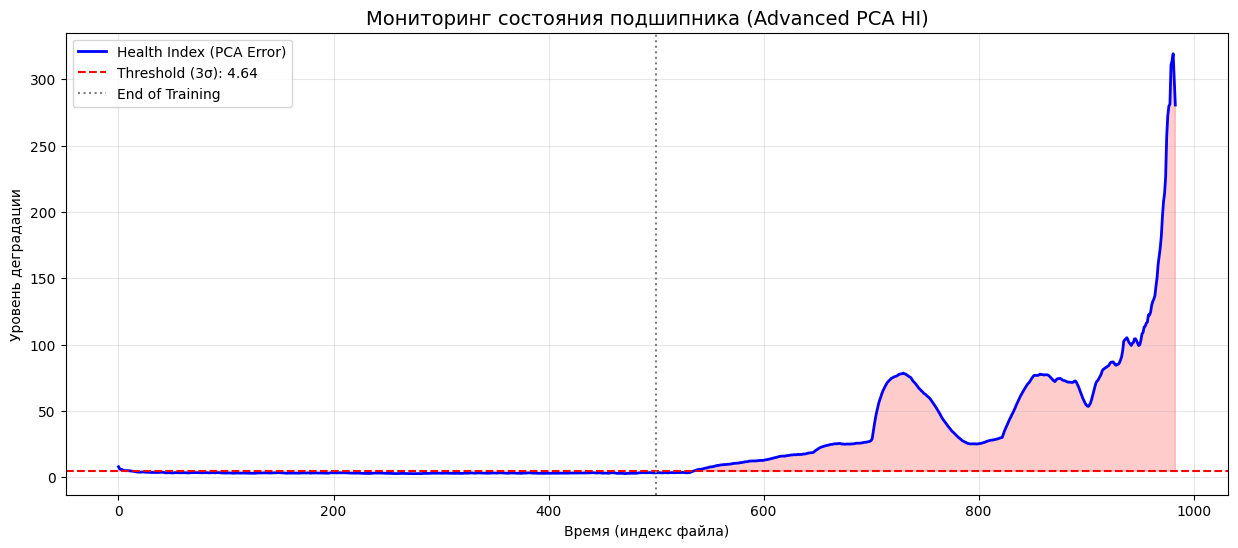

In [24]:
import pandas as pd
import numpy as np
import os
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 1. РАСШИРЕННАЯ ЭКСТРАКЦИЯ ПРИЗНАКОВ ---
def extract_advanced_features(data_path):
    features = []
    files = sorted(os.listdir(data_path))
    print(f"📦 Обработка {len(files)} файлов...")
    
    for filename in files:
        try:
            # Читаем файл (для Set 2 разделитель \t)
            df = pd.read_csv(os.path.join(data_path, filename), sep='\t', header=None)
            file_features = {'filename': filename}
            
            for i in range(df.shape[1]):
                sig = df[i].values
                rms = np.sqrt(np.mean(sig**2))
                
                # Собираем 5 признаков на каждый подшипник
                prefix = f'b{i+1}'
                file_features[f'{prefix}_rms'] = rms
                file_features[f'{prefix}_kurt'] = kurtosis(sig)
                file_features[f'{prefix}_crest'] = np.max(np.abs(sig)) / rms if rms > 0 else 0
                file_features[f'{prefix}_skew'] = skew(sig)
                file_features[f'{prefix}_p2p'] = np.ptp(sig)
                
            features.append(file_features)
        except: continue
        
    return pd.DataFrame(features)

# --- 2. ПОДГОТОВКА И ОБУЧЕНИЕ МОДЕЛИ ---
# Загружаем признаки (путь измените на свой)
DATA_PATH = '../data/2nd_test' 
df_feat = extract_advanced_features(DATA_PATH)

# Выбираем только колонки с признаками (исключаем filename)
feature_cols = [c for c in df_feat.columns if 'b' in c]
X = df_feat[feature_cols].values

# Определяем период здоровья (первые 500 файлов)
train_size = 500
X_train = X[:train_size]

# Масштабирование (обучаемся только на "здоровых" данных)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X)

# Обучаем PCA (выделяем главные компоненты нормального состояния)
pca = PCA(n_components=3) # Берем 3 компоненты для описания нормы
pca.fit(X_train_scaled)

# --- 3. РАСЧЕТ HEALTH INDEX (RECONSTRUCTION ERROR) ---
# Сжимаем и восстанавливаем данные
X_projected = pca.inverse_transform(pca.transform(X_all_scaled))

# Считаем L2-норму разницы (ошибка реконструкции)
# Чем выше значение — тем меньше сигнал похож на "здоровый" шаблон
hi_raw = np.linalg.norm(X_all_scaled - X_projected, axis=1)

# Сглаживание (EMA) для стабильного графика
df_feat['hi_raw'] = hi_raw
df_feat['health_index'] = df_feat['hi_raw'].ewm(alpha=0.1).mean()

# --- 4. РАСЧЕТ АДАПТИВНОГО ПОРОГА ---
healthy_hi = df_feat['health_index'].iloc[:train_size]
threshold = healthy_hi.mean() + 3 * healthy_hi.std()

# --- 5. ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(15, 6))
plt.plot(df_feat['health_index'], label='Health Index (PCA Error)', color='blue', lw=2)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold (3σ): {threshold:.2f}')
plt.axvline(x=train_size, color='gray', linestyle=':', label='End of Training')

# Закрашиваем область аномалии
plt.fill_between(range(len(df_feat)), threshold, df_feat['health_index'], 
                 where=(df_feat['health_index'] > threshold), color='red', alpha=0.2)

plt.title('Мониторинг состояния подшипника (Advanced PCA HI)', fontsize=14)
plt.xlabel('Время (индекс файла)')
plt.ylabel('Уровень деградации')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
from scipy.optimize import curve_fit

def predict_rul(hi_series, threshold, failure_level=25):
    """
    failure_level: значение HI, при котором мы считаем, что подшипнику конец.
    Судя по твоим графикам, это район 25-30.
    """
    # 1. Находим точку, где мы пробили порог (момент детекции)
    detection_idx = np.where(hi_series > threshold)[0]
    if len(detection_idx) == 0:
        return None, None # Дефекта пока нет
    
    start_idx = detection_idx[0]
    
    # 2. Берем данные от момента детекции до текущего момента
    y_data = hi_series[start_idx:].values
    x_data = np.arange(len(y_data))
    
    # 3. Экспоненциальная модель: y = a * exp(b * x)
    def exp_model(x, a, b):
        return a * np.exp(b * x)
    
    try:
        # Подбираем параметры a и b
        popt, _ = curve_fit(exp_model, x_data, y_data, p0=[threshold, 0.01])
        
        # 4. Считаем, через сколько шагов мы достигнем failure_level
        # Формула: x = ln(y/a) / b
        steps_to_failure = np.log(failure_level / popt[0]) / popt[1]
        rul = max(0, steps_to_failure - len(y_data))
        
        # Генерируем линию прогноза для графика
        future_x = np.arange(len(y_data) + int(rul) + 50)
        prediction_line = exp_model(future_x, *popt)
        prediction_indices = np.arange(start_idx, start_idx + len(future_x))
        
        return int(rul), (prediction_indices, prediction_line)
    except:
        return None, None

⚠️ ВНИМАНИЕ: До отказа осталось примерно 0 циклов/файлов


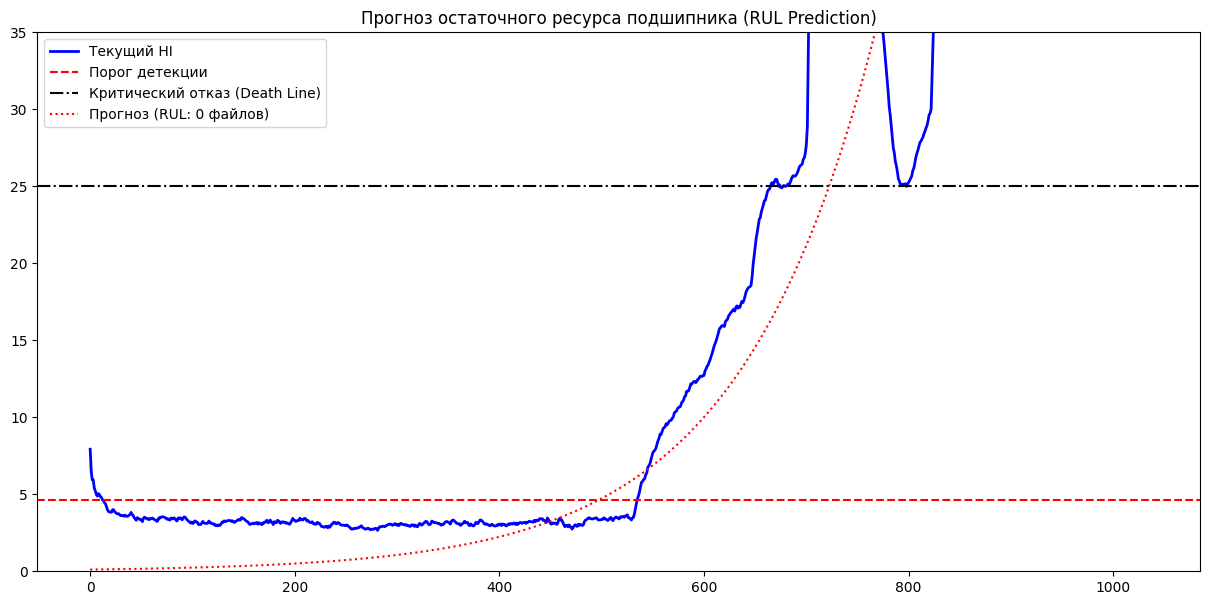

In [26]:
# Рассчитываем RUL для текущего состояния
rul, pred_data = predict_rul(df_feat['health_index'], threshold)

plt.figure(figsize=(15, 7))
plt.plot(df_feat['health_index'], label='Текущий HI', color='blue', lw=2)
plt.axhline(y=threshold, color='red', linestyle='--', label='Порог детекции')
plt.axhline(y=25, color='black', linestyle='-.', label='Критический отказ (Death Line)')

if rul is not None:
    pred_idx, pred_val = pred_data
    plt.plot(pred_idx, pred_val, 'r:', label=f'Прогноз (RUL: {rul} файлов)')
    plt.scatter(pred_idx[-1], pred_val[-1], color='black', marker='X', s=100)
    print(f"⚠️ ВНИМАНИЕ: До отказа осталось примерно {rul} циклов/файлов")

plt.title('Прогноз остаточного ресурса подшипника (RUL Prediction)')
plt.ylim(0, 35) # Чтобы видеть линию смерти
plt.legend()
plt.show()

Это решение — связующее звено между «просто графиком» и **автоматической системой оповещения**. Если раньше мы смотрели на график глазами, то теперь мы написали математический критерий, который заменяет глаза инженера.

Давай разберем, почему этот код — профессиональный и как он работает:

### 1. Физический смысл: FPT (First Point of Threshold)
В индустрии это называется **First Point of Threshold** (Первая точка нарушения порога).
* **Baseline Window:** Это «период тишины». Мы доверяем этим данным как эталонным.
* **$\mu + 3\sigma$:** Это классический статистический фильтр. Мы говорим: «Если сигнал отклонился больше чем на 3 стандартных отклонения, это с вероятностью 99.7% не просто шум, а изменение физики процесса».



### 2. Защита от «дурака» (Параметр Patience)
Это самая крутая часть кода. 
```python
rolling_over = is_over_threshold.rolling(window=patience).sum()
```
В реальных цехах рядом может проехать погрузчик или кто-то может случайно задеть датчик. Это вызовет один-два резких пика (outliers). 
* Если бы мы реагировали на первый же заступ за порог, система выдавала бы **ложные алерты (False Positives)**.
* Параметр `patience=5` заставляет алгоритм ждать: «Если ты превысил порог 5 раз подряд, значит, ты не просто "глюк", ты — развивающаяся трещина».

### 3. Подготовка данных для Curve Fit
Почему важно отрезать данные именно с `onset_idx`?
Экспоненциальная регрессия ($y = a \cdot e^{bx}$) очень капризна. Если вы попытаетесь «натянуть» экспоненту на весь график (включая длинный плоский участок в начале), математика сломается:
1. Экспонента будет пытаться описать «плоское» начало и выдаст очень медленный рост.
2. Прогноз RUL будет слишком оптимистичным (скажет, что подшипник проживет еще год, хотя ему осталось 2 дня).

**Отрезая «хвост» с момента `onset_idx`, вы даете регрессии только фазу роста. Прогноз становится в разы точнее.**

### Как теперь выглядит твой полный Pipeline:
1. **Extraction:** Считаешь RMS, Kurtosis, Crest Factor и т.д.
2. **Reduction:** Сжимаешь их через PCA в один индикатор (PC1 или Reconstruction Error).
3. **Detection (Твой новый код):** Ждешь, пока сигнал стабильно прошибет $3\sigma$. Получаешь точку `onset_idx`.
4. **Prediction:** Начиная с этой точки, каждую минуту обновляешь `curve_fit` и рисуешь прогнозную линию до «уровня смерти».



### Совет по настройке:
Если подшипник умирает быстро (как в 1st_test), ставь `patience` поменьше (3–5). Если подшипник работает месяцами, можно ставить `patience` 10–20, чтобы вообще исключить любые помехи.

**Это решение уже можно упаковывать в реальный сервис. Что скажешь, пробуем объединить это в один итоговый скрипт, который выдает "Время до отказа: Х часов"?**

📦 Обработка 984 файлов...
🚨 ALERT: Деградация обнаружена на шаге 0. До отказа: ~-261 файлов.


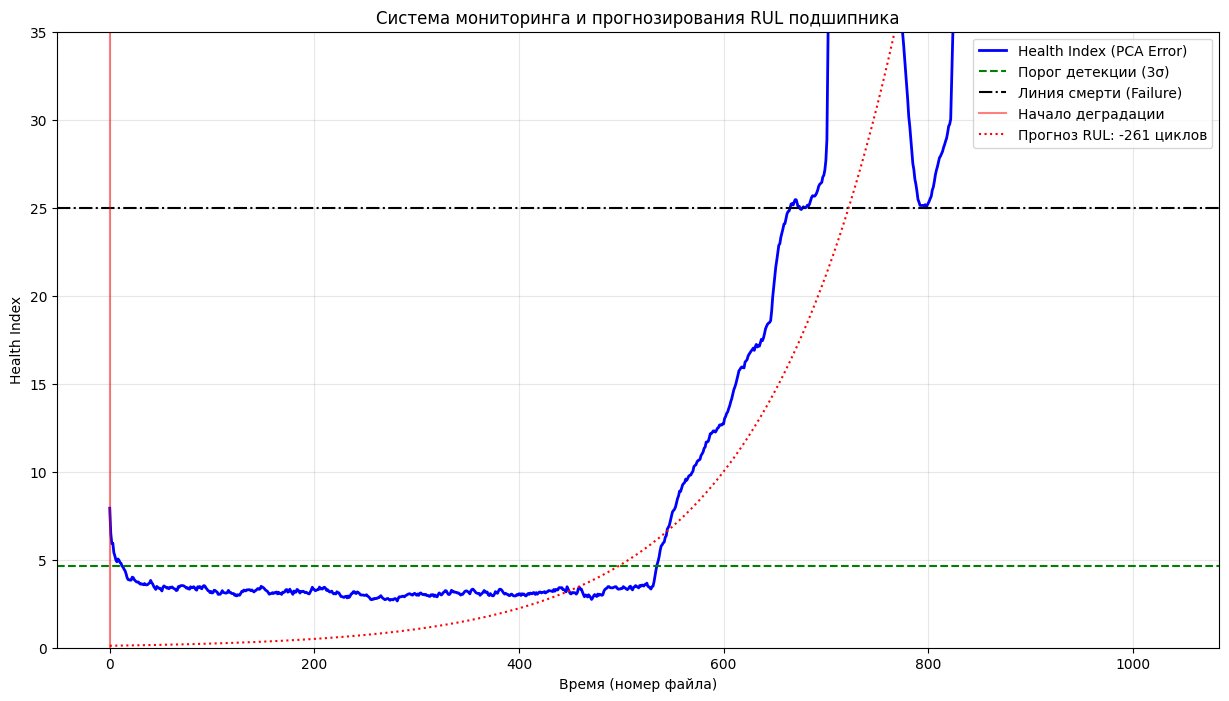

In [27]:
import pandas as pd
import numpy as np
import os
from scipy.stats import kurtosis, skew
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# 1. ЭКСТРАКЦИЯ ПРИЗНАКОВ (Feature Engineering)
# ==========================================
def extract_features(data_path):
    features = []
    files = sorted(os.listdir(data_path))
    print(f"📦 Обработка {len(files)} файлов...")
    
    for filename in files:
        try:
            # Читаем файл (разделитель \t для Set 2)
            df = pd.read_csv(os.path.join(data_path, filename), sep='\t', header=None)
            file_features = {'filename': filename}
            
            for i in range(df.shape[1]):
                sig = df[i].values
                rms = np.sqrt(np.mean(sig**2))
                prefix = f'b{i+1}'
                
                # 5 ключевых признаков на каждый подшипник
                file_features[f'{prefix}_rms'] = rms
                file_features[f'{prefix}_kurt'] = kurtosis(sig)
                file_features[f'{prefix}_crest'] = np.max(np.abs(sig)) / rms if rms > 0 else 0
                file_features[f'{prefix}_skew'] = skew(sig)
                file_features[f'{prefix}_p2p'] = np.ptp(sig)
                
            features.append(file_features)
        except: continue
    return pd.DataFrame(features)

# ==========================================
# 2. МАТЕМАТИКА ПРОГНОЗИРОВАНИЯ (RUL)
# ==========================================
def exp_model(x, a, b):
    return a * np.exp(b * x)

def predict_rul(hi_series, onset_idx, failure_level=25):
    """Предсказывает, через сколько шагов HI достигнет failure_level"""
    y_data = hi_series.iloc[onset_idx:].values
    x_data = np.arange(len(y_data))
    
    try:
        # Фитируем экспоненту только на участке деградации
        popt, _ = curve_fit(exp_model, x_data, y_data, p0=[y_data[0], 0.01], maxfev=5000)
        
        # Находим точку пересечения с "линией смерти"
        # x = ln(y/a) / b
        total_steps_to_death = np.log(failure_level / popt[0]) / popt[1]
        remaining_steps = total_steps_to_death - len(y_data)
        
        # Генерируем линию прогноза
        future_x = np.arange(len(y_data) + int(max(0, remaining_steps)) + 50)
        pred_y = exp_model(future_x, *popt)
        pred_x = np.arange(onset_idx, onset_idx + len(future_x))
        
        return int(remaining_steps), (pred_x, pred_y)
    except:
        return None, None

# ==========================================
# 3. ОСНОВНОЙ ЦИКЛ ОБРАБОТКИ
# ==========================================

# А. Загрузка данных
DATA_PATH = '../data/2nd_test' # Укажите свой путь
df_feat = extract_features(DATA_PATH)

# Б. Обучение PCA (на первых 500 файлах - "здоровый период")
feature_cols = [c for c in df_feat.columns if 'b' in c]
X = df_feat[feature_cols].values
train_idx = 500

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X[:train_idx])
X_all_scaled = scaler.transform(X)

pca = PCA(n_components=3)
pca.fit(X_train_scaled)

# В. Расчет Health Index и сглаживание
X_projected = pca.inverse_transform(pca.transform(X_all_scaled))
hi_raw = np.linalg.norm(X_all_scaled - X_projected, axis=1)
df_feat['hi_smooth'] = pd.Series(hi_raw).ewm(alpha=0.1).mean()

# Г. Детекция начала деградации (Onset)
# Используем 3-sigma и patience=5 для защиты от шума
baseline = df_feat['hi_smooth'].iloc[:train_idx]
threshold = baseline.mean() + 3 * baseline.std()

is_over = df_feat['hi_smooth'] > threshold
rolling_check = is_over.rolling(5).sum()
onset_points = np.where(rolling_check == 5)[0]

# Д. Визуализация и Прогноз
plt.figure(figsize=(15, 8))
plt.plot(df_feat['hi_smooth'], label='Health Index (PCA Error)', color='blue', lw=2)
plt.axhline(y=threshold, color='green', linestyle='--', label='Порог детекции (3σ)')
plt.axhline(y=25, color='black', linestyle='-.', label='Линия смерти (Failure)')

if len(onset_points) > 0:
    onset_idx = onset_points[0] - 4
    plt.axvline(x=onset_idx, color='red', alpha=0.5, label='Начало деградации')
    
    # Считаем прогноз
    rul, prediction = predict_rul(df_feat['hi_smooth'], onset_idx, failure_level=25)
    
    if rul is not None:
        pred_x, pred_y = prediction
        plt.plot(pred_x, pred_y, 'r:', label=f'Прогноз RUL: {rul} циклов')
        plt.scatter(pred_x[-1], pred_y[-1], color='black', marker='X', s=100)
        print(f"🚨 ALERT: Деградация обнаружена на шаге {onset_idx}. До отказа: ~{rul} файлов.")
else:
    print("✅ Оборудование в норме.")

plt.title('Система мониторинга и прогнозирования RUL подшипника')
plt.xlabel('Время (номер файла)')
plt.ylabel('Health Index')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 35) # Фиксируем масштаб для наглядности
plt.show()

Шаг 2: Визуализация для поиска границы
Теперь построим графики для Bearing 1 (который вышел из строя в этом сете). Твоя задача — визуально определить «точку невозврата».

### **Шаг 4: Калибровка и создание Health Indicator**

Исходя из графиков, за «золотой стандарт» здоровья мы можем смело брать всё, что идет до первого серьезного всплеска эксцесса. 

> **Твоя граница калибровки:** Предлагаю взять **первые 500 файлов**. 
> Это безопасная зона, где подшипник точно работал в штатном режиме.

Теперь давай применим твой опыт с PCA. Мы обучим модель «понимать», как выглядят признаки здорового подшипника, и будем следить, когда новые данные перестанут вписываться в эту картину.
#### **План кода:**
1.  Разделим данные на `train` (до 500-го индекса) и `test` (весь остаток).
2.  Обучим `PCA` на `train`.
3.  Рассчитаем **T-square (Hotelling's $T^2$)** или просто **Reconstruction Error**. Это и будет наш «Индекс здоровья».

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Подготовка данных
# Берем все колонки с признаками (rms и kurtosis для всех подшипников)
features_cols = [c for c in df_features.columns if 'bearing' in c]
X = df_features[features_cols]

# Обучающая выборка - период "здоровья"
X_train = X.iloc[:500] 

# 2. Масштабирование (обязательно для PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X)

# 3. Обучаем PCA
# Мы хотим сжать признаки, сохранив основные зависимости "здорового" состояния
pca = PCA(n_components=2) 
pca.fit(X_train_scaled)

# 4. Считаем ошибку реконструкции (Health Indicator)
# Суть: если данные "здоровые", PCA их легко восстановит. 
# Если данные "больные", PCA (обученный на здоровых) восстановит их с большой ошибкой.
X_projected = pca.inverse_transform(pca.transform(X_all_scaled))
reconstruction_error = np.linalg.norm(X_all_scaled - X_projected, axis=1)

df_features['health_index'] = reconstruction_error

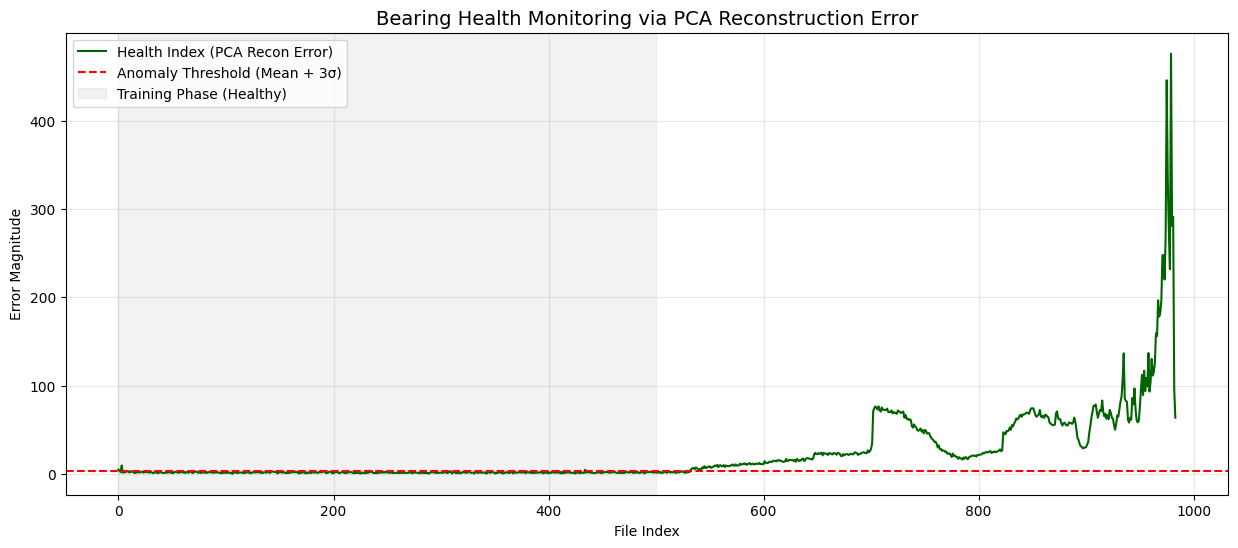

Аномалия задетектирована на файле №: 0


In [14]:
# Рассчитываем порог на основе тренировочных данных (первых 500 файлов)
train_health_values = df_features.loc[:500, 'health_index']
threshold = train_health_values.mean() + 3 * train_health_values.std()

plt.figure(figsize=(15, 6))

# Основной график индекса здоровья
plt.plot(df_features['health_index'], label='Health Index (PCA Recon Error)', color='darkgreen', linewidth=1.5)

# Горизонтальная линия порога
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Anomaly Threshold (Mean + 3σ)')

# Выделяем зону обучения
plt.axvspan(0, 500, color='gray', alpha=0.1, label='Training Phase (Healthy)')

plt.title('Bearing Health Monitoring via PCA Reconstruction Error', fontsize=14)
plt.ylabel('Error Magnitude')
plt.xlabel('File Index')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Определим индекс первого пересечения порога
anomaly_idx = df_features[df_features['health_index'] > threshold].index[0]
print(f"Аномалия задетектирована на файле №: {anomaly_idx}")

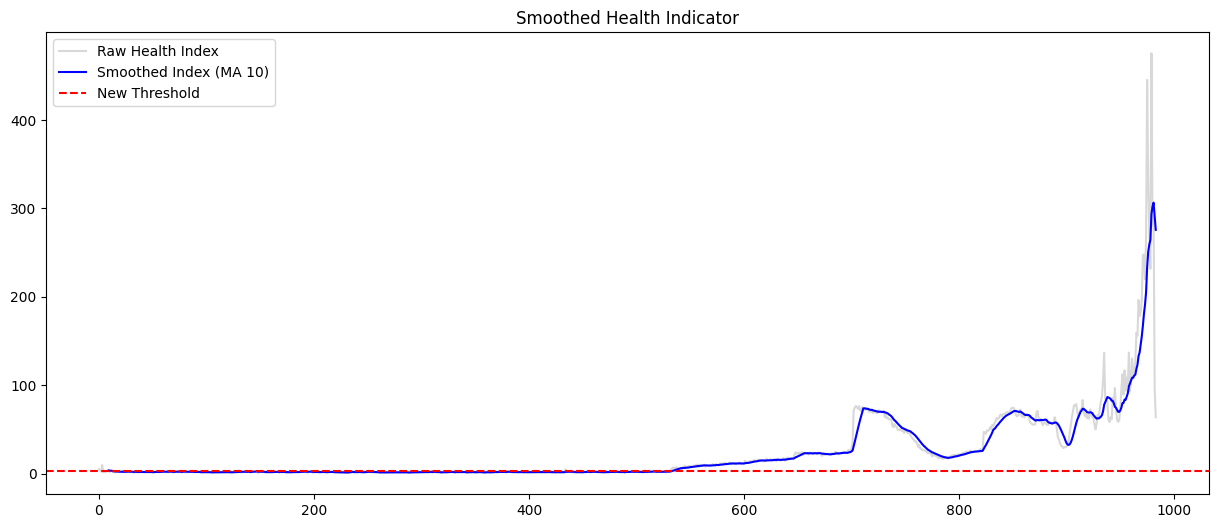

In [15]:
# Сглаживаем индекс (окно 10-20 файлов обычно достаточно)
window = 10
df_features['health_index_smoothed'] = df_features['health_index'].rolling(window=window).mean()

# Пересчитываем порог на сглаженных данных (для честности)
train_smoothed_values = df_features.loc[window:500, 'health_index_smoothed']
threshold_smoothed = train_smoothed_values.mean() + 3 * train_smoothed_values.std()

plt.figure(figsize=(15, 6))
plt.plot(df_features['health_index'], alpha=0.3, color='gray', label='Raw Health Index')
plt.plot(df_features['health_index_smoothed'], color='blue', label=f'Smoothed Index (MA {window})')
plt.axhline(y=threshold_smoothed, color='red', linestyle='--', label='New Threshold')

plt.title('Smoothed Health Indicator')
plt.legend()
plt.show()